[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/03_Model_evaluation_selection/preprocessing_pipelines.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

### Data Preprocessing, Feature Engineering & Pipelines

Real datasets have missing values, text categories, skewed numbers and features on wildly different scales. How you handle them often matters more than which model you pick. And handling them *wrongly* (fitting any preprocessing on data that includes the validation or test set) silently inflates your scores. This is **data leakage**.

This notebook implements the core transformers from scratch, checks them against scikit-learn, and then assembles them into a leak-proof `Pipeline`.

Theory: [Data Preprocessing & Pipelines](README.md#data-preprocessing--pipelines)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder, OrdinalEncoder, RobustScaler,
                                   StandardScaler, TargetEncoder)

from mlf_utils import check_close

sns.set_theme(style="whitegrid")
np.random.seed(42)

#### A realistic messy dataset
A synthetic housing dataset, generated here so the notebook runs offline and the ground truth is known:
- `area_sqft`: right-skewed (log-normal), **8% missing completely at random (MCAR)**
- `bedrooms`, `year_built`: numeric
- `neighborhood`: nominal category (no order)
- `condition`: ordinal category (Poor < Fair < Good < Excellent), **missing more often for old houses (MAR)**
- `has_garage`: boolean
- target `price`: multiplicative in the features, so it's right-skewed too

In [3]:
rng = np.random.RandomState(0)
n = 2000
neighborhoods = np.array(["Downtown", "Hills", "Industrial", "Riverside", "Suburb"])
neighborhood_effect = {"Downtown": 1.5, "Hills": 1.8, "Industrial": 0.7, "Riverside": 1.2, "Suburb": 1.0}
condition_levels = ["Poor", "Fair", "Good", "Excellent"]
condition_effect = {"Poor": 0.75, "Fair": 0.9, "Good": 1.0, "Excellent": 1.2}

df = pd.DataFrame({
    "area_sqft": rng.lognormal(mean=7.3, sigma=0.35, size=n).round(),
    "year_built": rng.randint(1920, 2023, n),
    "neighborhood": rng.choice(neighborhoods, n, p=[0.2, 0.1, 0.15, 0.2, 0.35]),
    "condition": rng.choice(condition_levels, n, p=[0.1, 0.3, 0.4, 0.2]),
    "has_garage": rng.rand(n) < 0.6,
})
df["bedrooms"] = np.clip(np.round(df["area_sqft"] / 450 + rng.normal(0, 0.8, n)), 1, 8).astype(int)
df["price"] = (120 * df["area_sqft"] ** 0.9
               * df["neighborhood"].map(neighborhood_effect) * df["condition"].map(condition_effect)
               * (1 + 0.004 * (df["year_built"] - 1950)) * (1 + 0.08 * df["has_garage"])
               * np.exp(rng.normal(0, 0.12, n))).round(-2)

# Inject missing values: MCAR for area, MAR (depends on age) for condition
df.loc[rng.rand(n) < 0.08, "area_sqft"] = np.nan
old = df["year_built"] < 1960
df.loc[(old & (rng.rand(n) < 0.35)) | (~old & (rng.rand(n) < 0.05)), "condition"] = np.nan
df.head()

,area_sqft,year_built,neighborhood,condition,has_garage,bedrooms,price
0,2745.0,1949,Suburb,Fair,True,6,142800.0
1,1703.0,1991,Hills,Good,True,3,227400.0
2,2085.0,1946,Industrial,Fair,True,5,75700.0
3,3243.0,2015,Hills,Good,True,6,408300.0
4,2846.0,1934,Riverside,NaN,True,8,187500.0


area_sqft       float64
year_built        int64
neighborhood        str
condition           str
has_garage         bool
bedrooms          int64
price           float64 

Missing values per column:
area_sqft       166
year_built        0
neighborhood      0
condition       332
has_garage        0
bedrooms          0
price             0


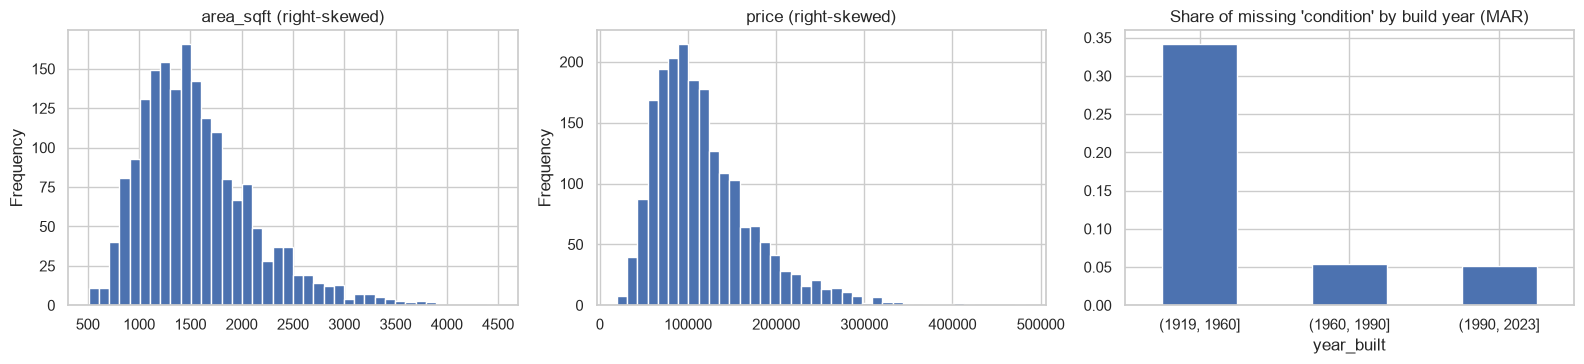

In [4]:
print(df.dtypes.to_string(), "\n")
print("Missing values per column:\n" + df.isna().sum().to_string())
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
df["area_sqft"].plot.hist(bins=40, ax=axes[0], title="area_sqft (right-skewed)")
df["price"].plot.hist(bins=40, ax=axes[1], title="price (right-skewed)")
df.groupby(pd.cut(df["year_built"], [1919, 1960, 1990, 2023]), observed=True)["condition"].apply(lambda s: s.isna().mean()).plot.bar(
    ax=axes[2], rot=0, title="Share of missing 'condition' by build year (MAR)")
plt.tight_layout(); plt.show()

In [5]:
X = df.drop(columns="price")
y = np.log(df["price"])                  # model log-price: turns multiplicative effects into additive ones
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape

((1500, 6), (500, 6))

### 1. Missing values
| Mechanism | Meaning | Example | Safe to impute simply? |
|---|---|---|---|
| **MCAR** | Missingness unrelated to anything | a sensor randomly drops readings | Yes (mean/median) |
| **MAR** | Depends on *observed* features | condition unrecorded for old houses | Mostly, especially with a missing indicator |
| **MNAR** | Depends on the *missing value itself* | high earners skip the income question | No: missingness itself carries information |

**Median imputation** is robust to skew and outliers. A **missing-indicator** column (1 if the value was missing) lets the model learn from the missingness pattern itself. The imputation statistics must be learned from the **training set only**.

In [6]:
class ScratchMedianImputer:
    def fit(self, X):
        self.statistics_ = np.nanmedian(X, axis=0)          # learned from training data only
        return self

    def transform(self, X, add_indicator=False):
        X = np.array(X, dtype=float)
        missing = np.isnan(X)
        X[missing] = np.take(self.statistics_, np.where(missing)[1])
        return np.hstack([X, missing.astype(float)]) if add_indicator else X

num_cols = ["area_sqft", "year_built", "bedrooms"]
ours = ScratchMedianImputer().fit(X_train[num_cols].values)
sk = SimpleImputer(strategy="median").fit(X_train[num_cols])
check_close("Median imputation vs SimpleImputer", ours.transform(X_test[num_cols].values), sk.transform(X_test[num_cols]))

sk_ind = SimpleImputer(strategy="median", add_indicator=True).fit(X_train[num_cols])
# sklearn only adds indicator columns for features that had missing values during fit
has_missing = np.isnan(X_train[num_cols].values).any(axis=0)
ours_ind = ours.transform(X_test[num_cols].values, add_indicator=True)
ours_ind = np.hstack([ours_ind[:, :3], ours_ind[:, 3:][:, has_missing]])
check_close("Median imputation + missing indicator vs SimpleImputer", ours_ind, sk_ind.transform(X_test[num_cols]))

✓ Median imputation vs SimpleImputer: matches (max |diff| = 0.00e+00)
✓ Median imputation + missing indicator vs SimpleImputer: matches (max |diff| = 0.00e+00)


### 2. Encoding categorical features
- **One-hot encoding** for *nominal* categories: one 0/1 column per category. Unseen categories at prediction time become all-zeros (`handle_unknown="ignore"`) instead of crashing.
- **Ordinal encoding** for *ordered* categories: map to integers **in the meaningful order** (Poor=0 < Fair=1 < …), not alphabetically.
- **Target encoding** for *high-cardinality* categories (thousands of zip codes): replace each category with the mean target of that category. It must be **cross-fitted**, or it leaks the target (see section 5).

In [7]:
class ScratchOneHotEncoder:
    def fit(self, column):
        self.categories_ = np.array(sorted(pd.unique(column)))
        return self

    def transform(self, column):
        column = np.asarray(column)
        return (column[:, None] == self.categories_[None, :]).astype(float)    # unseen -> all zeros

ohe_ours = ScratchOneHotEncoder().fit(X_train["neighborhood"])
ohe_sk = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X_train[["neighborhood"]])
check_close("One-hot encoding vs OneHotEncoder", ohe_ours.transform(X_test["neighborhood"]), ohe_sk.transform(X_test[["neighborhood"]]))

unseen = pd.DataFrame({"neighborhood": ["Hills", "Airport"]})         # "Airport" never appeared in training
print("Encoding of ['Hills', 'Airport']:\n", ohe_sk.transform(unseen), "\ncategories:", ohe_sk.categories_[0])

cond_order = {c: i for i, c in enumerate(condition_levels)}
known = X_test["condition"].notna()                                         # missing values are imputed before encoding
ours_ord = X_test.loc[known, "condition"].map(cond_order).to_numpy(dtype=float)
sk_ord = OrdinalEncoder(categories=[condition_levels]).fit(X_train[["condition"]].dropna()).transform(X_test.loc[known, ["condition"]])
check_close("Ordinal encoding (with explicit order) vs OrdinalEncoder", ours_ord, sk_ord.ravel(), atol=0)
print("Alphabetical order would have been:", sorted(condition_levels), "(meaningless for an ordered scale)")

✓ One-hot encoding vs OneHotEncoder: matches (max |diff| = 0.00e+00)
Encoding of ['Hills', 'Airport']:
 [[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]] 
categories: ['Downtown' 'Hills' 'Industrial' 'Riverside' 'Suburb']
✓ Ordinal encoding (with explicit order) vs OrdinalEncoder: matches (max |diff| = 0.00e+00)
Alphabetical order would have been: ['Excellent', 'Fair', 'Good', 'Poor'] (meaningless for an ordered scale)


### 3. Scaling
- **Standardisation:** $z = \frac{x - \mu}{\sigma}$, which is what distance-based and gradient-based models and regularised models need. It uses the population standard deviation ($n$, not $n-1$).
- **Robust scaling:** $\frac{x - \text{median}}{\text{IQR}}$, which isn't dragged around by outliers.
- **Min-max scaling:** squashes values into $[0, 1]$. It's fragile when outliers are present.

Tree-based models don't need scaling at all, because splits only depend on the *order* of values.

In [8]:
class ScratchStandardScaler:
    def fit(self, X):
        self.mean_, self.scale_ = X.mean(axis=0), X.std(axis=0)            # ddof=0, like sklearn
        return self
    def transform(self, X):
        return (X - self.mean_) / self.scale_

class ScratchRobustScaler:
    def fit(self, X):
        self.center_ = np.median(X, axis=0)
        q75, q25 = np.percentile(X, [75, 25], axis=0)
        self.scale_ = q75 - q25
        return self
    def transform(self, X):
        return (X - self.center_) / self.scale_

Xn_train = SimpleImputer(strategy="median").fit(X_train[num_cols]).transform(X_train[num_cols])
Xn_test = SimpleImputer(strategy="median").fit(X_train[num_cols]).transform(X_test[num_cols])
check_close("StandardScaler", ScratchStandardScaler().fit(Xn_train).transform(Xn_test), StandardScaler().fit(Xn_train).transform(Xn_test))
check_close("RobustScaler", ScratchRobustScaler().fit(Xn_train).transform(Xn_test), RobustScaler().fit(Xn_train).transform(Xn_test))

✓ StandardScaler: matches (max |diff| = 0.00e+00)
✓ RobustScaler: matches (max |diff| = 0.00e+00)


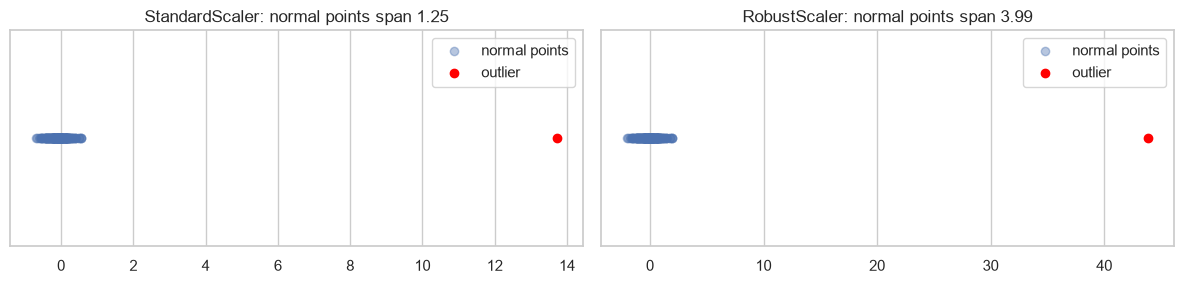

In [9]:
# One extreme outlier: standard scaling squeezes all the normal points together, robust scaling doesn't
values = np.r_[rng.normal(0, 1, 200), 60.0].reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, (name, scaler) in zip(axes, [("StandardScaler", StandardScaler()), ("RobustScaler", RobustScaler())]):
    scaled = scaler.fit_transform(values).ravel()
    ax.scatter(scaled[:-1], np.zeros(200), alpha=0.4, label="normal points")
    ax.scatter(scaled[-1:], [0], color="red", label="outlier")
    ax.set_yticks([]); ax.set_title(f"{name}: normal points span {np.ptp(scaled[:-1]):.2f}"); ax.legend()
plt.tight_layout(); plt.show()

### 4. Feature engineering & the full pipeline
Good features encode what you know about the problem:
- **Log-transform** skewed positive variables. Price scales multiplicatively with area here, so $\log(\text{area})$ is linear in $\log(\text{price})$.
- **Derived features**, such as house age from `year_built`, ratios, or date parts (day of week, month).
- **Interactions** and polynomial terms when effects combine.

A `ColumnTransformer` applies a different preprocessing chain to each group of columns, and a `Pipeline` chains it with the model. Calling `cross_val_score` on the pipeline **refits every step inside every fold**, so no statistic from the validation fold ever leaks into training.

Below we add one improvement at a time and measure the 5-fold cross-validated $R^2$ on the training set.

In [10]:
numeric_basic = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
numeric_log = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                        ("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler())])
nominal = OneHotEncoder(handle_unknown="ignore")
ordinal = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("encode", OrdinalEncoder(categories=[condition_levels]))])
condition_missing = MissingIndicator()              # separate 0/1 column: "condition was not recorded"

steps = {
    "1. numeric columns only (median + scale)": ColumnTransformer([("num", numeric_basic, num_cols)]),
    "2. + log transform & missing indicators": ColumnTransformer([("num", numeric_log, num_cols)]),
    "3. + one-hot neighborhood": ColumnTransformer([("num", numeric_log, num_cols), ("nom", nominal, ["neighborhood"])]),
    "4. + ordinal condition & garage": ColumnTransformer([("num", numeric_log, num_cols), ("nom", nominal, ["neighborhood"]),
                                                          ("ord", ordinal, ["condition"]), ("ord_missing", condition_missing, ["condition"]),
                                                          ("bool", "passthrough", ["has_garage"])]),
}
cv = KFold(5, shuffle=True, random_state=0)
results = {}
for name, preprocess in steps.items():
    pipe = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])
    results[name] = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2").mean()
pd.Series(results, name="CV R²").round(3).to_frame()

,CV R²
1. numeric columns only (median + scale),0.449
2. + log transform & missing indicators,0.466
3. + one-hot neighborhood,0.808
4. + ordinal condition & garage,0.876


In [11]:
final_pipe = Pipeline([("prep", steps["4. + ordinal condition & garage"]), ("model", Ridge(alpha=1.0))]).fit(X_train, y_train)
print(f"Held-out test R² of the final pipeline: {final_pipe.score(X_test, y_test):.3f}")
final_pipe

Held-out test R² of the final pipeline: 0.894


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['area_sqft','year_built','neighborhood','condition','has_garage', 'bedrooms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colum

### 5. Data leakage: two classic traps
**Trap 1: feature selection before cross-validation.** 100 samples, 5,000 features of **pure noise** and random labels, so the honest accuracy is 50%. Selecting the 20 "best" features on the *full* dataset first, then cross-validating, makes noise look predictive, because the selector already saw the validation folds' labels.

In [12]:
rng_leak = np.random.RandomState(1)
X_noise, y_noise = rng_leak.randn(100, 5000), rng_leak.randint(0, 2, 100)
cv_clf = KFold(5, shuffle=True, random_state=0)

X_selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)            # leaky: uses all labels
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_selected, y_noise, cv=cv_clf).mean()
honest = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000)),
                         X_noise, y_noise, cv=cv_clf).mean()
print(f"Leaky   (select, then CV):          accuracy = {leaky:.3f}")
print(f"Honest  (selection inside pipeline): accuracy = {honest:.3f}   <- the truth: noise is noise")

Leaky   (select, then CV):          accuracy = 0.860
Honest  (selection inside pipeline): accuracy = 0.550   <- the truth: noise is noise


**Trap 2: naive target encoding.** Add a high-cardinality `street_id` with 800 levels that has **no relationship** to price. Encoding each street by its mean log-price over the whole training set lets each row's own target leak into its feature (many streets have only one or two houses), so the model appears to learn something. `TargetEncoder` **cross-fits**: each row is encoded using means computed on the *other* folds, and it shrinks rare categories towards the global mean.

In [13]:
X_street = X_train.assign(street_id=rng.randint(0, 800, len(X_train)).astype(str))
street_means = y_train.groupby(X_street["street_id"]).mean()                     # leaky: includes each row's own target
X_street_naive = X_street["street_id"].map(street_means).to_frame()

naive_r2 = cross_val_score(Ridge(), X_street_naive, y_train, cv=cv, scoring="r2").mean()
honest_r2 = cross_val_score(make_pipeline(TargetEncoder(target_type="continuous"), Ridge()),
                            X_street[["street_id"]], y_train, cv=cv, scoring="r2").mean()
print(f"Naive mean encoding of a meaningless ID: CV R² = {naive_r2:.3f}")
print(f"TargetEncoder inside a pipeline:         CV R² = {honest_r2:.3f}   <- ≈ 0 (or below): there is no signal")

Naive mean encoding of a meaningless ID: CV R² = 0.422
TargetEncoder inside a pipeline:         CV R² = -0.014   <- ≈ 0 (or below): there is no signal


#### Try it: missing data and imputation strategy
Knock out a growing fraction of `area_sqft` (the strongest feature) completely at random and compare strategies by cross-validated $R^2$. *Drop rows* throws data away, while *median* keeps every row. The *+ indicator* variant adds a 0/1 missing flag, which helps most when missingness is informative (MAR/MNAR). Here it's MCAR, so expect only a small gain.

*Interactive: run the notebook locally or in Colab to use the controls. GitHub only renders a static page.*

In [14]:
from ipywidgets import Dropdown, FloatSlider, interact

@interact(missing_fraction=FloatSlider(value=0.3, min=0.0, max=0.9, step=0.05, continuous_update=False),
          strategy=Dropdown(options=["drop rows", "mean", "median", "median + indicator"], value="median"))
def explore_missing(missing_fraction, strategy):
    Xm = X_train.copy()
    mask = np.random.RandomState(0).rand(len(Xm)) < missing_fraction
    Xm.loc[mask, "area_sqft"] = np.nan
    ym = y_train
    if strategy == "drop rows":
        keep = Xm["area_sqft"].notna()
        Xm, ym = Xm[keep], ym[keep]
    imputer = SimpleImputer(strategy="mean" if strategy == "mean" else "median",
                            add_indicator=strategy == "median + indicator")
    prep = ColumnTransformer([("num", Pipeline([("impute", imputer), ("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler())]), num_cols),
                              ("nom", nominal, ["neighborhood"]), ("ord", ordinal, ["condition"]),
                              ("ord_missing", condition_missing, ["condition"]), ("bool", "passthrough", ["has_garage"])])
    score = cross_val_score(Pipeline([("prep", prep), ("model", Ridge())]), Xm, ym, cv=cv, scoring="r2").mean()
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.barh(["CV R²"], [score], color="tab:blue"); ax.set_xlim(0, 1)
    ax.set_title(f"{missing_fraction:.0%} of area missing, '{strategy}': R² = {score:.3f} on {len(Xm)} rows")
    plt.show()

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='missing_fraction', max=0.9,…

#### Preprocessing checklist
1. **Split first.** Fit every imputer, scaler, encoder and feature selector on the training data only, ideally by putting them in a `Pipeline`.
2. **Missing values:** median or most-frequent imputation, plus missing indicators when missingness might be informative. Understand *why* values are missing.
3. **Categoricals:** one-hot for nominal, ordinal with an explicit order for ordered categories, cross-fitted target encoding for high cardinality. Always handle unseen categories.
4. **Numeric:** log-transform skewed positive features. Standardise for linear, distance-based and neural models. Use robust scaling when outliers are present. Trees don't need scaling.
5. **Targets:** transform skewed targets (e.g. log), and remember to invert the transform for predictions.
6. **Validate honestly:** cross-validate the *whole* pipeline, and touch the test set once.